In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Set style for visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [14]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

In [15]:
df_train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
#Print dataset info
print('Training set info')
print(df_train.info())

print('\n' + '=' * 50)

#Missing Data
print('\nMissing Values')
missing = pd.DataFrame({
    'Columns': df_train.columns,
    'Missing Count': df_train.isnull().sum(),
    'Missing Percentage': (df_train.isnull().sum() / df_train.shape[0]) * 100
})
print(missing[missing['Missing Count'] > 0])


print('\n' + '=' * 50)

#Basic Statistics
print('\nBasic Statistics')
print(df_train.describe())

print('\n' + '=' * 50)

#Distribution of Target
print('\nDistribution of Target Variable (Survived)')
print(df_train['Survived'].value_counts())
print('Survival Rate: {:.2f}%'.format(df_train['Survived'].mean() * 100))


Training set info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Missing Values
           Columns  Missing Count  Missing Percentage
Age            Age            177           19.865320
Cabin        Cabin            687           77.104377
Embarked  Embarked              2         

In [17]:
missing = pd.DataFrame({
    'Train Missing': df_train.isnull().sum(),
    'Train %': df_train.isnull().sum() / len(df_train),
    'Test Missing': df_test.isnull().sum(),
    'Test %': df_test.isnull().sum() / len(df_test)
}).query('`Train Missing` > 0 or `Test Missing` > 0')
print(missing)

          Train Missing   Train %  Test Missing    Test %
Age                 177  0.198653          86.0  0.205742
Cabin               687  0.771044         327.0  0.782297
Embarked              2  0.002245           0.0  0.000000
Fare                  0  0.000000           1.0  0.002392


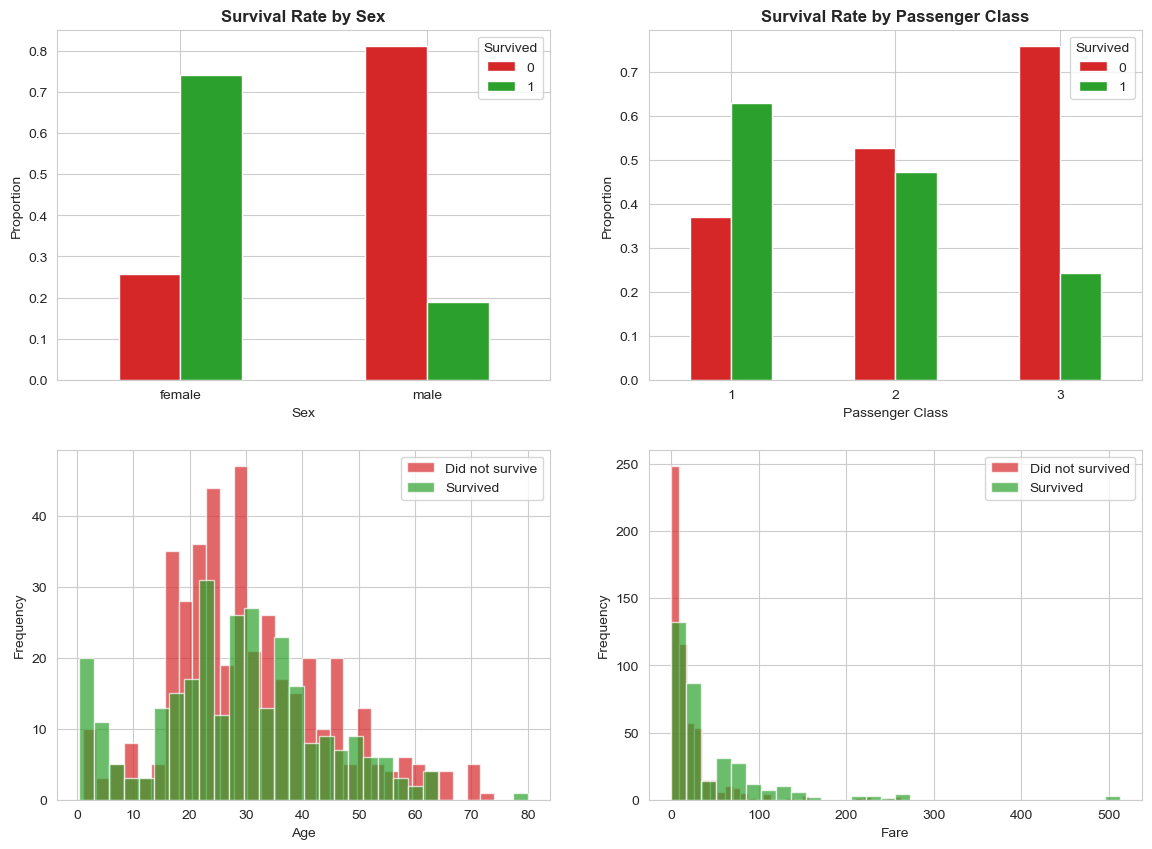

In [18]:
# Feature Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by Sex
pd.crosstab(df_train['Sex'], df_train['Survived'], normalize='index').plot(kind='bar', ax=axes[0, 0], color=['#d62728', '#2ca02c'])
axes[0, 0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0, 0].set_xlabel('Sex')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# Survival by Pclass
pd.crosstab(df_train['Pclass'], df_train['Survived'], normalize='index').plot(kind='bar', ax=axes[0, 1], color=['#d62728', '#2ca02c'])
axes[0, 1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0, 1].set_xlabel('Passenger Class')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# Age Distribution by Survival
df_train[df_train['Survived'] == 0]['Age'].plot(kind = 'hist', ax=axes[1, 0], bins=30, alpha= 0.7, label='Did not survive', color='#d62728')
df_train[df_train['Survived'] == 1]['Age'].plot(kind = 'hist', ax=axes[1, 0], bins=30, alpha = 0.7, label='Survived', color ='#2ca02c')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Age Distribution by Fare
df_train[df_train['Survived'] == 0]['Fare'].plot(kind = 'hist', ax=axes[1, 1], bins = 30, alpha = 0.7, label = 'Did not survived', color='#d62728')
df_train[df_train['Survived'] == 1]['Fare'].plot(kind = 'hist', ax=axes[1, 1], bins = 30, alpha = 0.7, label = 'Survived', color='#2ca02c')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

# Data Cleaning
1) Remove Unnecessary Columns
2) Fix data types
3) Drop duplicates
4) Consisteny check: Typos mess up categorical encoding later
5) Logical check - Data Quality Issues
6) Outlier Analysis
    - if outliers are measurement errors - REMOVE
    - elif outliers are natural but rare - Keep them
    - elif outliers will cause modeling problems - keep but transform  -> log scaling, capping
    - elif outliers affect interpretability - consider removal or separate analysis

In [19]:
'''
1) Don't remove missing ages - Impute (19.9 % missing)
2) Remove rows with missing embarked - Remove Rows
3) Drop Cabin Column (77.1 % missing)
'''

df = df_train.copy()

# Step1: Check duplicates BEFORE removing identifying columns
print('Checking duplicates before dropping identifier columns:')
print(f'Duplicate rows BEFORE: {df.duplicated().sum()}')
print('=' * 60)

# Step2: Extract Title BEFORE dropping Name
print("Extracting title from Name before dropping Name")
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print("\nInitial titles extracted:")
print(df['Title'].value_counts())

# Define rare titles
rare_titles = [
    'Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
    'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'
]

# Replace rare titles with 'Rare'
df.loc[df['Title'].isin(rare_titles), 'Title'] = 'Rare'

# Standardize title variations
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("\nSimplified titles:")
print(df['Title'].value_counts())
print('=' * 60)

# Step3: Remove unnecessary columns
print('Drop Columns:\nPassengerId, Ticket, Name, Cabin')
df.drop(['PassengerId', 'Ticket', 'Name', 'Cabin'], axis=1, inplace=True)
print('=' * 60)

# Step4: Fix data types
df['Pclass'] = df['Pclass'].astype('object')
df['Sex'] = df['Sex'].astype('object')
df['Embarked'] = df['Embarked'].astype('object')
df['Title'] = df['Title'].astype('object')

# Step5: DO NOT drop duplicates after removing identifiers
print('Duplicate check after dropping identifier columns:')
print(f'Duplicate-looking rows: {df.duplicated().sum()}')
print('Note: These are not removed because they may be real passengers with identical values.')
print('=' * 60)

# Step6: Remove rows with minimal missing data and impute Age
print('\nHandling Missing Values:')
print(f'Before: Missing Embarked = {df["Embarked"].isnull().sum()}')
print(f'Before: Missing Age = {df["Age"].isnull().sum()}')

# Step7: Drop rows with missing Embarked
df = df.dropna(subset=['Embarked']).reset_index(drop=True)

# Step8: Impute Age using class-aware median
df['Age'] = df['Age'].fillna(
    df.groupby('Pclass')['Age'].transform('median')
)

print(f'After: Missing Embarked = {df["Embarked"].isnull().sum()}')
print(f'After: Missing Age = {df["Age"].isnull().sum()}')

# Step9: Fix categorical consistency
df['Sex'] = df['Sex'].str.lower().str.strip()
df['Embarked'] = df['Embarked'].str.strip()

# Step10: Outlier Analysis
print('\nOutlier check:')
print(f"Age range: {df['Age'].min():.0f} to {df['Age'].max():.0f}")
print(f"Fare range: {df['Fare'].min():.2f} to {df['Fare'].max():.2f}")

# Step11: Final verification
print("\n" + "=" * 60)
print("CLEANED DATA SUMMARY")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Checking duplicates before dropping identifier columns:
Duplicate rows BEFORE: 0
Extracting title from Name before dropping Name

Initial titles extracted:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Simplified titles:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64
Drop Columns:
PassengerId, Ticket, Name, Cabin
Duplicate check after dropping identifier columns:
Duplicate-looking rows: 105
Note: These are not removed because they may be real passengers with identical values.

Handling Missing Values:
Before: Missing Embarked = 2
Before: Missing Age = 177
After: Missing Embarked = 0
After: Missing Age = 0

Outlier check:
Age range: 0 to 80
Fare range: 0.00 to 512.33

CLEANED DA

# Feature Engineering
- Does it have domain meaning
- Is it derived logically from raw data
- Could this feature be predictive for the model
- Will the model be able to learn from this feature
- Is this feature independent or redundant with existing ones?


1) Domain-Based: Business/Domain Logic
Family Relationships
Social Status
Economic Status
Age groups

2) Feature Transformation: Continuous variables to categorical bins when they have non-linear relationships
Age Binning
Fare Binning

3) Feature interaction
Ex)
Pclass x Sex
Family Size x Fare

In [20]:
# FEATURE ENGINEERING - Creating Core 4 Features
print("\nFEATURE ENGINEERING - Creating Core 4 Features")
print("Family Size, IsAlone, Title, AgeBin")
print("=" * 70)

# 1) Title already extracted from raw data
print("\n1. Title already extracted from Name")
print("-" * 70)

print("\nSimplified titles:")
print(df['Title'].value_counts())

print("\nSurvival rate by Title:")
print(pd.crosstab(df['Title'], df['Survived'], normalize='index'))

# 2) Create FAMILY SIZE Feature
print("\n" + "=" * 70)
print("2. CREATING FAMILY SIZE FEATURES")
print("-" * 70)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("\nFamilySize distribution:")
print(df['FamilySize'].value_counts().sort_index())

print("\nIsAlone distribution:")
print(df['IsAlone'].value_counts())

print("\nSurvival rate by FamilySize:")
print(pd.crosstab(df['FamilySize'], df['Survived'], normalize='index'))

print("\nSurvival rate by IsAlone:")
print(pd.crosstab(df['IsAlone'], df['Survived'], normalize='index'))

# 3) Binning Age - 5 categories
print("\n" + "=" * 70)
print("3. BINNING AGE INTO 5 CATEGORIES")
print("-" * 70)

df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'],
    include_lowest=True
)

print("\nAgeBin distribution:")
print(df['AgeBin'].value_counts().sort_index())

print("\nSurvival rate by AgeBin:")
print(pd.crosstab(df['AgeBin'], df['Survived'], normalize='index'))

# 4) BINNING FARE INTO 4 QUARTILES
print("\n" + "=" * 70)
print("4. BINNING FARE INTO 4 QUARTILES")
print("-" * 70)

df['FareBin'] = pd.qcut(
    df['Fare'],
    q=4,
    duplicates='drop',
    labels=['Low', 'Medium', 'High', 'VeryHigh']
)

print("\nFareBin distribution:")
print(df['FareBin'].value_counts())

print("\nSurvival rate by FareBin:")
print(pd.crosstab(df['FareBin'], df['Survived'], normalize='index'))

# 5) Keep categorical features as categories
print("\n" + "=" * 70)
print("5. KEEPING CATEGORICAL FEATURES UNENCODED")
print("-" * 70)

print("Sex kept as category: male/female")
print("Embarked kept as category: S/C/Q")
print("Title kept as category: Mr/Mrs/Miss/Master/Rare")
print("AgeBin kept as category: Child/Teen/Adult/Middle-aged/Senior")
print("FareBin kept as category: Low/Medium/High/VeryHigh")
print("These will be one-hot encoded later inside the ML pipeline.")

# Feature Engineering Summary
print("\n" + "=" * 70)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 70)

print("\nOriginal features: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']")

print("\nNew features created:")
print("Title (extracted from Name)")
print("FamilySize (SibSp + Parch + 1)")
print("IsAlone (binary)")
print("AgeBin (5 categories: Child, Teen, Adult, Middle-aged, Senior)")
print("FareBin (4 categories: Low, Medium, High, VeryHigh)")

print(f"\nFinal dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# Data Set Preview and Summary Statistics
print("\nDataset preview (first 10 rows):")
print(df.head(10))

print("\nFeature engineering summary statistics:")
print(df.describe(include='all'))


FEATURE ENGINEERING - Creating Core 4 Features
Family Size, IsAlone, Title, AgeBin

1. Title already extracted from Name
----------------------------------------------------------------------

Simplified titles:
Title
Mr        517
Miss      184
Mrs       125
Master     40
Rare       23
Name: count, dtype: int64

Survival rate by Title:
Survived         0         1
Title                       
Master    0.425000  0.575000
Miss      0.298913  0.701087
Mr        0.843327  0.156673
Mrs       0.208000  0.792000
Rare      0.652174  0.347826

2. CREATING FAMILY SIZE FEATURES
----------------------------------------------------------------------

FamilySize distribution:
FamilySize
1     535
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

IsAlone distribution:
IsAlone
1    535
0    354
Name: count, dtype: int64

Survival rate by FamilySize:
Survived           0         1
FamilySize                    
1           0.699065  0.300935
2

In [24]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Numerical Features
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
]

# Categorical Features
categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "IsAlone",
    "AgeBin",
    "FareBin"
]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing -> Standardize numerical values and one-hot encode categorical values
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Create Logistic Regression Model
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# Train Model
baseline_model.fit(X_train, y_train)

# Predict
y_pred = baseline_model.predict(X_test)

# Evaluate
print("Baseline Logistic Regression Results")
print("=" * 50)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Logistic Regression Results
Accuracy: 0.8426966292134831

Confusion Matrix:
[[101   9]
 [ 19  49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       110
           1       0.84      0.72      0.78        68

    accuracy                           0.84       178
   macro avg       0.84      0.82      0.83       178
weighted avg       0.84      0.84      0.84       178



# Cross Validation
Using K-Fold Cross Validation
-> k-1 folds used for training, 1 fold use for testing
-> Rotates so that every fold gets a turn to be the test set
-> Aggregate: You end up with K different performance scores. These scores are then averaged to produce a single, highly reliable metric for the model's performance.

## Stratified K-Fold:
Ensures that each fold contains the same proportion for observations for each category or class.

In [34]:
# ============================================================
# PHASE 7: STRATIFIED K-FOLD CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 1. Define X and y
# ------------------------------------------------------------

X = df.drop(columns=["Survived"])
y = df["Survived"]

# ------------------------------------------------------------
# 2. Create Stratified K-Fold object
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 3. Define evaluation metrics
# ------------------------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# ------------------------------------------------------------
# 4. Run cross-validation
# ------------------------------------------------------------

cv_results = cross_validate(
    estimator=baseline_model,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# ------------------------------------------------------------
# 5. Convert results into readable table
# ------------------------------------------------------------

results_df = pd.DataFrame(cv_results)

print("Raw Cross-Validation Results")
print("=" * 60)
print(results_df)

# ------------------------------------------------------------
# 6. Summarize mean and standard deviation
# ------------------------------------------------------------

summary = results_df.agg(["mean", "std"]).T

print("\nCross-Validation Summary")
print("=" * 60)
print(summary)

# ------------------------------------------------------------
# 7. Focus only on model performance metrics
# ------------------------------------------------------------

metric_columns = [
    "train_accuracy",
    "test_accuracy",
    "train_precision",
    "test_precision",
    "train_recall",
    "test_recall",
    "train_f1",
    "test_f1"
]

performance_summary = results_df[metric_columns].agg(["mean", "std"]).T

print("\nPerformance Summary")
print("=" * 60)
print(performance_summary)

Raw Cross-Validation Results
   fit_time  score_time  test_accuracy  train_accuracy  test_precision  \
0  0.025810    0.019875       0.831461        0.835443        0.779412   
1  0.024280    0.026670       0.825843        0.834037        0.793651   
2  0.024647    0.010515       0.808989        0.839662        0.793103   
3  0.024613    0.011789       0.848315        0.829817        0.805970   
4  0.020607    0.015148       0.836158        0.832865        0.782609   

   train_precision  test_recall  train_recall   test_f1  train_f1  
0         0.799228     0.779412      0.761029  0.779412  0.779661  
1         0.805556     0.735294      0.746324  0.763359  0.774809  
2         0.801527     0.676471      0.772059  0.730159  0.786517  
3         0.793774     0.794118      0.750000  0.800000  0.771267  
4         0.797665     0.794118      0.753676  0.788321  0.775047  

Cross-Validation Summary
                     mean       std
fit_time         0.023991  0.001979
score_time       0.0

# Cross-Validation Results and Analysis

## Cross-Validation Setup

To evaluate the robustness and generalization ability of the baseline Logistic Regression model, a 5-Fold Stratified Cross-Validation procedure was performed. Stratified folds were used to ensure that the survival-to-non-survival ratio remained consistent across all folds.

## Mean Cross-Validation Performance

| Metric    | Mean Score |
| --------- | ---------- |
| Accuracy  | 0.830      |
| Precision | 0.791      |
| Recall    | 0.756      |
| F1-Score  | 0.772      |

## Interpretation of Results

### Model Performance

The Logistic Regression model achieved a mean accuracy of **83.0%**, indicating that the model correctly classified passenger survival outcomes in approximately 83% of cases.

The model achieved a precision score of **79.1%**, meaning that when the model predicted a passenger would survive, the prediction was correct roughly 79% of the time.

The recall score was **75.6%**, indicating that the model successfully identified approximately 76% of all passengers who actually survived.

The F1-score of **77.2%** suggests a reasonably balanced trade-off between precision and recall.

### Train vs Test Performance

The average training scores and testing scores were very similar across folds. This suggests that the model is not significantly overfitting the training data and is able to generalize well to unseen data.

### Weakest Metric

Among all evaluation metrics, **Recall** was the lowest-performing metric.

This indicates that the model tends to miss some passengers who actually survived (False Negatives). While the model is fairly reliable when predicting survival, it does not identify all survivors successfully.

### Stability of the Model

The standard deviation of the evaluation metrics across folds was relatively low.

This indicates that the model's performance remains consistent across different train-validation splits, suggesting that the Logistic Regression model is stable and generalizes well across the dataset.

## Conclusion

The baseline Logistic Regression model demonstrates strong and consistent performance, achieving approximately **83% accuracy** with relatively balanced precision and recall. The model shows little evidence of overfitting and exhibits stable performance across multiple validation folds.

The primary area for future improvement is increasing **Recall**, which would allow the model to identify a greater proportion of actual survivors. Future experimentation may include alternative models such as Decision Trees, Random Forests, and Gradient Boosting methods, as well as additional feature engineering and hyperparameter tuning.
